In [60]:
#!pip install yfinance

In [1]:
import yfinance as yf
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import bs4 as bs
import requests
import seaborn as sns

In [2]:
# Pegando todos os tickers do S&P500
url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"
}

resp = requests.get(url, headers=headers)
soup = bs.BeautifulSoup(resp.text, "lxml")

table = soup.find("table", {"id": "constituents"})  # tabela principal
tickers = []
for row in table.find_all("tr")[1:]:
    ticker = row.find_all("td")[0].text.strip()
    tickers.append(ticker)

print(len(tickers))
tickers[:10]

503


['MMM', 'AOS', 'ABT', 'ABBV', 'ACN', 'ADBE', 'AMD', 'AES', 'AFL', 'A']

In [3]:
soup

<!DOCTYPE html>
<html class="client-nojs vector-feature-language-in-header-enabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector-feature-limited-width-clientpref-1 vector-feature-limited-width-content-enabled vector-feature-custom-font-size-clientpref-1 vector-feature-appearance-pinned-clientpref-1 vector-feature-night-mode-enabled skin-theme-clientpref-day vector-sticky-header-enabled vector-toc-available" dir="ltr" lang="en">
<head>
<meta charset="utf-8"/>
<title>List of S&amp;P 500 companies - Wikipedia</title>
<script>(function(){var className="client-js vector-feature-language-in-header-enabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector-feature-limited-width-clientpref-1 vector-feature-limited-width-content-ena

In [3]:
# Salvar para uso futuro
# data.to_csv("dados_2006_2007.csv")
# data_full.to_csv("dados_full_1997_2007.csv")

# Carregar de volta os DataFrames
data = pd.read_csv("dados_2006_2007.csv", index_col=0)
data_full = pd.read_csv("dados_full_1997_2007.csv", index_col=0)

data.head()

,MMM,AOS,ABT,ACN,ADBE,AMD,AES,AFL,A,APD,...,WDC,WY,WSM,WMB,WTW,WYNN,XEL,YUM,ZBRA,ZBH
Date,,,,,,,,,,,,,,,,,,,,,
2006-01-03,37.081547,4.466237,12.043580,20.727745,38.520000,32.400002,10.594819,14.750942,20.099953,34.221111,...,11.519893,12.624354,13.915199,8.324626,62.774403,29.063988,9.076958,11.604428,42.830002,59.318142
2006-01-04,36.894047,4.490475,12.061859,20.840939,38.419998,32.560001,11.046078,14.833289,20.153952,33.830730,...,11.907521,12.929356,13.615329,8.376873,63.426319,29.010126,9.120948,11.703718,42.410000,59.881184
2006-01-05,36.556564,4.448058,12.217154,20.996572,38.070000,33.680000,10.941437,14.953654,20.681948,33.537956,...,11.792443,12.815689,13.455826,8.289795,62.465599,28.837723,9.116060,12.202649,42.529999,59.248859
2006-01-06,36.856556,4.600766,12.451633,22.036497,39.000000,33.779999,11.118017,15.488960,20.789949,34.318707,...,12.052884,12.834638,13.551526,8.321140,61.710732,29.112476,9.150272,12.167892,44.119999,58.945667
2006-01-09,37.039375,4.757120,12.914498,21.972824,38.380001,33.250000,10.928357,15.561815,20.729950,33.882404,...,12.803917,12.804320,13.889683,8.456982,64.215515,30.486214,9.125832,12.262219,44.790001,61.033234


In [5]:
# Baixar dados históricos

# substituir 'BRK.B' por 'BRK-B' )em todos os casos)
# def download_one_ticker(ticker, start, end, max_retries=3, delay=5):
#     for attempt in range(max_retries):
#         try:
#             sanitized = ticker.replace(".", "-")
#             df = yf.download(sanitized, start=start, end=end, auto_adjust=True,
#                              progress=False, threads=False, timeout=30)
            
#             if not df.empty:
#                 return df["Close"]
#             else:
#                 return None
                
#         except Exception as e:
#             err_msg = str(e)
#             print(err_msg)
            
#             # Outros erros → re-tenta
#             time.sleep(delay)

#     return None

# start_date_full = "1997-01-02"
# start_date = "2006-01-02"
# end_date = "2007-12-31"

# dict_data = {}
# dict_data_full = {}
# data_fail = []
# data_full_fail = []

# for ticker in tickers:
#     data_ticker = download_one_ticker(ticker, start_date, end_date)
#     print(ticker)
#     if data_ticker is not None:
#         dict_data[ticker] = data_ticker
#     else:
#         data_fail.append(ticker)

#     data_ticker_full = download_one_ticker(ticker, start_date_full, end_date)
#     if data_ticker_full is not None:
#         dict_data_full[ticker] = data_ticker_full
#     else:
#         data_full_fail.append(ticker)

# # Construir DataFrames
# data = pd.concat(dict_data.values(), axis=1)
# data.columns = dict_data.keys()

# data_full = pd.concat(dict_data_full.values(), axis=1)
# data_full.columns = dict_data_full.keys()
# data.head()

# Salvar para uso futuro
# data.to_csv("dados_2006_2007.csv")
# data_full.to_csv("dados_full_1997_2007.csv")

In [4]:
data_full.head()

,MMM,AOS,ABT,ACN,ADBE,AMD,AES,AFL,A,APD,...,WDC,WY,WSM,WMB,WTW,WYNN,XEL,YUM,ZBRA,ZBH
Date,,,,,,,,,,,,,,,,,,,,,
1997-01-02,16.557709,1.968470,5.582990,NaN,4.734613,13.5625,7.418825,3.155399,NaN,16.411489,...,16.618141,6.832460,2.766412,4.945474,NaN,NaN,6.785945,NaN,10.333333,NaN
1997-01-03,16.269743,1.951928,5.707671,NaN,4.795901,14.0000,7.398387,3.164598,NaN,16.682501,...,17.337374,6.832460,2.871085,5.030447,NaN,NaN,6.804490,NaN,10.722222,NaN
1997-01-06,16.293741,1.927115,5.638408,NaN,4.964447,14.2500,7.602762,3.201396,NaN,16.772846,...,18.094473,6.923078,2.701612,5.098428,NaN,NaN,6.841568,NaN,10.888889,NaN
1997-01-07,16.101768,1.985012,5.763087,NaN,5.163639,14.9375,7.684513,3.182998,NaN,16.712626,...,18.018761,7.013694,2.781365,5.200395,NaN,NaN,6.878652,NaN,11.888889,NaN
1997-01-08,16.077768,1.976742,5.679967,NaN,5.178962,14.4375,7.745826,3.201396,NaN,16.802954,...,18.737993,7.068064,2.721551,5.251381,NaN,NaN,6.952816,NaN,11.666667,NaN


In [5]:
start_date_full = "1997-01-02"
start_date = "2006-01-02"
end_date = "2007-12-31"

data_spy = yf.download("SPY", start=start_date, end=end_date, auto_adjust=True)["Close"]
data_spy_full = yf.download("SPY", start=start_date_full, end=end_date, auto_adjust=True)["Close"]

data_spy.head()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Ticker,SPY
Date,
2006-01-03,87.721718
2006-01-04,88.137108
2006-01-05,88.192528
2006-01-06,88.926414
2006-01-09,89.154915


In [6]:
# Calcular retornos diários
returns = data.pct_change()
returns.dropna(inplace=True,axis=0, how='all')
returns.dropna(inplace=True,axis=1, how='any')

returns_full = data_full.pct_change()
returns_full.dropna(inplace=True,axis=0, how='all')
returns_full.dropna(inplace=True,axis=1, how='any')

returns_spy = data_spy.pct_change()
returns_spy.dropna(inplace=True,axis=0, how='all')
returns_spy.dropna(inplace=True,axis=1, how='any')

returns_spy_full = data_spy_full.pct_change()
returns_spy_full.dropna(inplace=True,axis=0, how='all')
returns_spy_full.dropna(inplace=True,axis=1, how='any')

returns.head()

,MMM,AOS,ABT,ACN,ADBE,AMD,AES,AFL,A,APD,...,WDC,WY,WSM,WMB,WTW,WYNN,XEL,YUM,ZBRA,ZBH
Date,,,,,,,,,,,,,,,,,,,,,
2006-01-04,-0.005056,0.005427,0.001518,0.005461,-0.002596,0.004938,0.042592,0.005582,0.002687,-0.011408,...,0.033649,0.024160,-0.021550,0.006276,0.010385,-0.001853,0.004846,0.008556,-0.009806,0.009492
2006-01-05,-0.009147,-0.009446,0.012875,0.007468,-0.009110,0.034398,-0.009473,0.008115,0.026198,-0.008654,...,-0.009664,-0.008791,-0.011715,-0.010395,-0.015147,-0.005943,-0.000536,0.042630,0.002829,-0.010560
2006-01-06,0.008206,0.034332,0.019193,0.049528,0.024429,0.002969,0.016139,0.035798,0.005222,0.023280,...,0.022085,0.001479,0.007112,0.003781,-0.012085,0.009528,0.003753,-0.002848,0.037385,-0.005117
2006-01-09,0.004960,0.033984,0.037173,-0.002889,-0.015897,-0.015690,-0.017059,0.004704,-0.002886,-0.012713,...,0.062311,-0.002362,0.024953,0.016325,0.040589,0.047187,-0.002671,0.007752,0.015186,0.035415
2006-01-10,-0.006201,0.023948,-0.009668,-0.021571,0.005993,0.050526,-0.006583,0.000814,0.013025,-0.011522,...,0.008988,0.013316,0.019062,0.008649,-0.010152,0.001237,0.004821,-0.000810,0.037285,-0.004257


In [7]:
returns_full.head()

,MMM,AOS,ABT,ADBE,AMD,AES,AFL,APD,ALB,LNT,...,WEC,WFC,WELL,WST,WDC,WY,WSM,WMB,XEL,ZBRA
Date,,,,,,,,,,,,,,,,,,,,,
1997-01-03,-0.017392,-0.008404,0.022332,0.012945,0.032258,-0.002755,0.002915,0.016514,-0.019608,0.004464,...,0.004672,0.020231,0.015544,-0.004465,0.043280,0.000000,0.037837,0.017182,0.002733,0.037634
1997-01-06,0.001475,-0.012712,-0.012135,0.035144,0.017857,0.027624,0.011628,0.005416,0.020000,0.004445,...,0.004651,-0.011332,-0.005102,-0.004484,0.043669,0.013263,-0.059027,0.013514,0.005449,0.015544
1997-01-07,-0.011782,0.030044,0.022112,0.040124,0.048246,0.010753,-0.005747,-0.003590,-0.006536,-0.004426,...,0.000000,0.011462,-0.010257,0.009009,-0.004184,0.013089,0.029520,0.020000,0.005420,0.091837
1997-01-08,-0.001491,-0.004166,-0.014423,0.002967,-0.033473,0.007979,0.005780,0.005405,-0.019737,0.000000,...,0.009260,0.005665,-0.010363,-0.008929,0.039916,0.007752,-0.021505,0.009804,0.010782,-0.018692
1997-01-09,-0.001492,-0.004185,0.009756,-0.020710,-0.047619,0.002639,-0.008620,-0.001792,0.013423,0.004445,...,0.018348,0.000000,0.020943,0.000000,0.020202,-0.002564,0.069597,0.019417,0.002666,0.038095


In [8]:
display(returns.mean())
returns.std()

MMM     0.000308
AOS     0.000229
ABT     0.000904
ACN     0.000624
ADBE    0.000380
          ...   
WYNN    0.002061
XEL     0.000637
YUM     0.001165
ZBRA   -0.000277
ZBH     0.000058
Length: 401, dtype: float64

MMM     0.011614
AOS     0.021684
ABT     0.011357
ACN     0.015595
ADBE    0.018172
          ...   
WYNN    0.024934
XEL     0.011289
YUM     0.014912
ZBRA    0.016741
ZBH     0.015221
Length: 401, dtype: float64

In [9]:
# Padronização dos retornos
mu_i = returns.mean()
sigma_i = returns.std()
Y = (returns - mu_i)/sigma_i

Y_full = (returns_full - returns_full.mean())/returns_full.std()
Y.head()

,MMM,AOS,ABT,ACN,ADBE,AMD,AES,AFL,A,APD,...,WDC,WY,WSM,WMB,WTW,WYNN,XEL,YUM,ZBRA,ZBH
Date,,,,,,,,,,,,,,,,,,,,,
2006-01-04,-0.461896,0.239724,0.054039,0.310138,-0.163758,0.266527,2.475828,0.360259,0.126837,-0.926943,...,1.313270,1.450894,-1.016633,0.317457,0.891273,-0.156965,0.372922,0.495690,-0.569213,0.619747
2006-01-05,-0.814139,-0.446166,1.054029,0.438813,-0.522195,1.312046,-0.602969,0.548340,1.487018,-0.724983,...,-0.440291,-0.566731,-0.535169,-0.690962,-1.347428,-0.320986,-0.103860,2.780748,0.185557,-0.697578
2006-01-06,0.680067,1.572703,1.610313,3.135792,1.323373,0.196640,0.911538,2.604647,0.273520,1.617231,...,0.845123,0.062104,0.386508,0.166538,-1.078903,0.299475,0.276063,-0.269116,2.249678,-0.340030
2006-01-09,0.400580,1.556687,3.193479,-0.225300,-0.895706,-0.465556,-1.051534,0.294981,-0.195540,-1.022707,...,2.473709,-0.173065,1.259919,0.925284,3.539619,1.809863,-0.293005,0.441767,0.923640,2.322822
2006-01-10,-0.560452,1.093870,-0.930821,-1.423187,0.308870,1.884436,-0.432051,0.006035,0.724913,-0.935307,...,0.314867,0.786905,0.971516,0.460980,-0.909466,-0.033023,0.370669,-0.132394,2.243686,-0.283538


In [10]:
# Calculando a matriz de correlação
corr_matrix = Y.corr()
corr_matrix_full = Y_full.corr()

corr_matrix.head()

,MMM,AOS,ABT,ACN,ADBE,AMD,AES,AFL,A,APD,...,WDC,WY,WSM,WMB,WTW,WYNN,XEL,YUM,ZBRA,ZBH
MMM,1.000000,0.233617,0.247571,0.208133,0.242899,0.175018,0.253134,0.336263,0.376592,0.439362,...,0.236256,0.374132,0.298393,0.272085,0.198557,0.236656,0.314490,0.299764,0.254543,0.203040
AOS,0.233617,1.000000,0.208440,0.265484,0.200147,0.203088,0.215254,0.233832,0.228673,0.347640,...,0.275472,0.371026,0.287917,0.235934,0.201353,0.218884,0.263169,0.289694,0.254592,0.172078
ABT,0.247571,0.208440,1.000000,0.224952,0.200951,0.144943,0.257341,0.388112,0.280268,0.364761,...,0.192838,0.340282,0.200823,0.182500,0.168157,0.242759,0.430465,0.294047,0.178662,0.175148
ACN,0.208133,0.265484,0.224952,1.000000,0.195496,0.177215,0.217893,0.263745,0.276139,0.289136,...,0.177004,0.270910,0.196648,0.196379,0.160663,0.202362,0.134653,0.239479,0.225472,0.179566
ADBE,0.242899,0.200147,0.200951,0.195496,1.000000,0.254135,0.199261,0.315688,0.303718,0.374555,...,0.196084,0.233678,0.195029,0.204273,0.177361,0.201448,0.274755,0.258044,0.258183,0.212827


array([119.16582534,  11.988182  ,  10.60121618,   8.2126816 ,
         6.06003598,   4.96473214,   4.27049877,   4.03857861,
         3.4335363 ,   3.21305215,   2.99207894,   2.91899816,
         2.68161858,   2.60773627,   2.57561032,   2.50523205,
         2.42227784,   2.37420199,   2.30288216,   2.26888953])

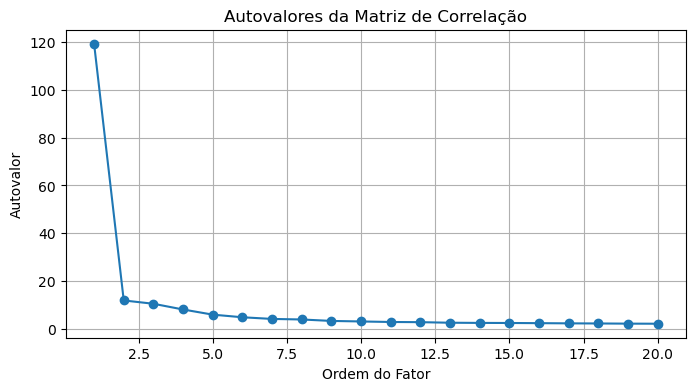

In [11]:
# PCA sobre matriz de correlação empírica
evals, evecs = np.linalg.eigh(corr_matrix)         
idx = np.argsort(evals)[::-1]                      
eigen_val  = evals[idx]
eigen_vec  = evecs[:, idx]                          

evals_f, evecs_f = np.linalg.eigh(corr_matrix_full)
idx_f = np.argsort(evals_f)[::-1]
eigen_val_full = evals_f[idx_f]
eigen_vec_full = evecs_f[:, idx_f]

display(eigen_val[:20])

# --- Visualização dos 20 maiores autovalores
plt.figure(figsize=(8, 4))
plt.plot(np.arange(1, min(20, len(eigen_val)) + 1), eigen_val[:20], 'o-')
plt.title("Autovalores da Matriz de Correlação")
plt.xlabel("Ordem do Fator")
plt.ylabel("Autovalor")
plt.grid(True)
plt.show()


(0.5, 25.0)

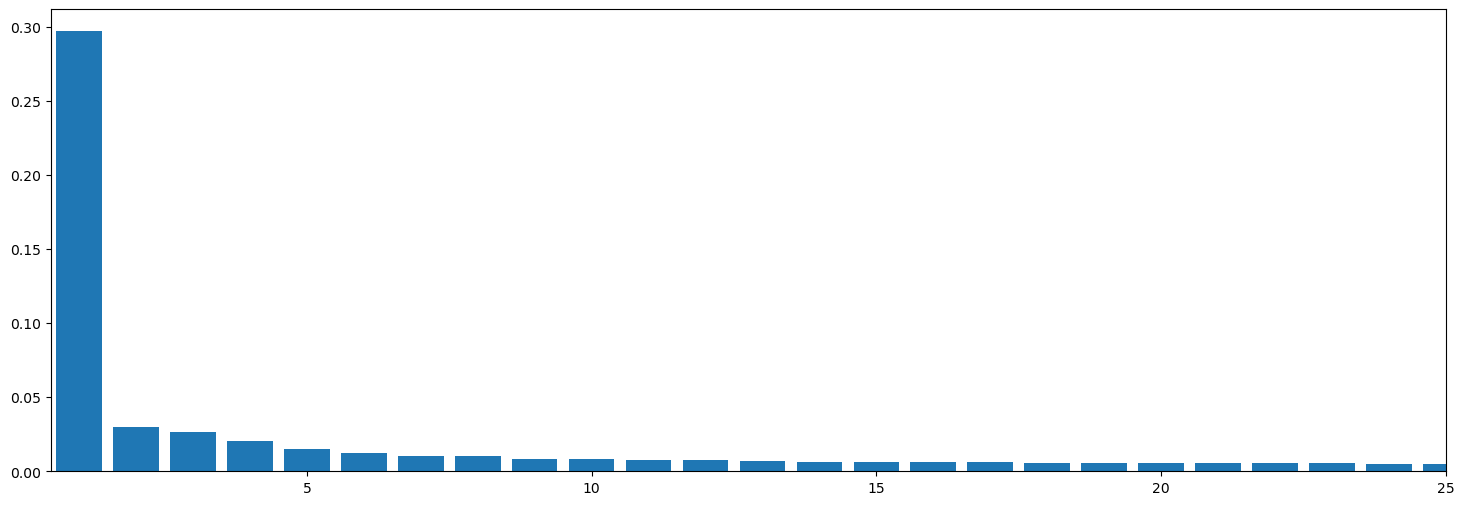

In [12]:
plt.figure(figsize=(18,6))
plt.bar(np.arange(1, len(eigen_val)+1),height = (eigen_val)/sum(eigen_val))
plt.xlim(0.5,25)
#plt.ylim(0,0.7)

In [13]:
# Pesos dos eigenportfólios
sigma = returns.std(ddof=1)
sigma_full = returns_full.std(ddof=1)

def eigen_weights(j):
    vj = pd.Series(eigen_vec[:, j], index=returns.columns)
    wj = vj / sigma
    wj = wj / wj.abs().sum()     # |w|=1 (controle de alavancagem)
    return wj

def eigen_weights_full(j):
    vj = pd.Series(eigen_vec_full[:, j], index=returns_full.columns)
    wj = vj / sigma_full
    wj = wj / wj.abs().sum()
    return wj

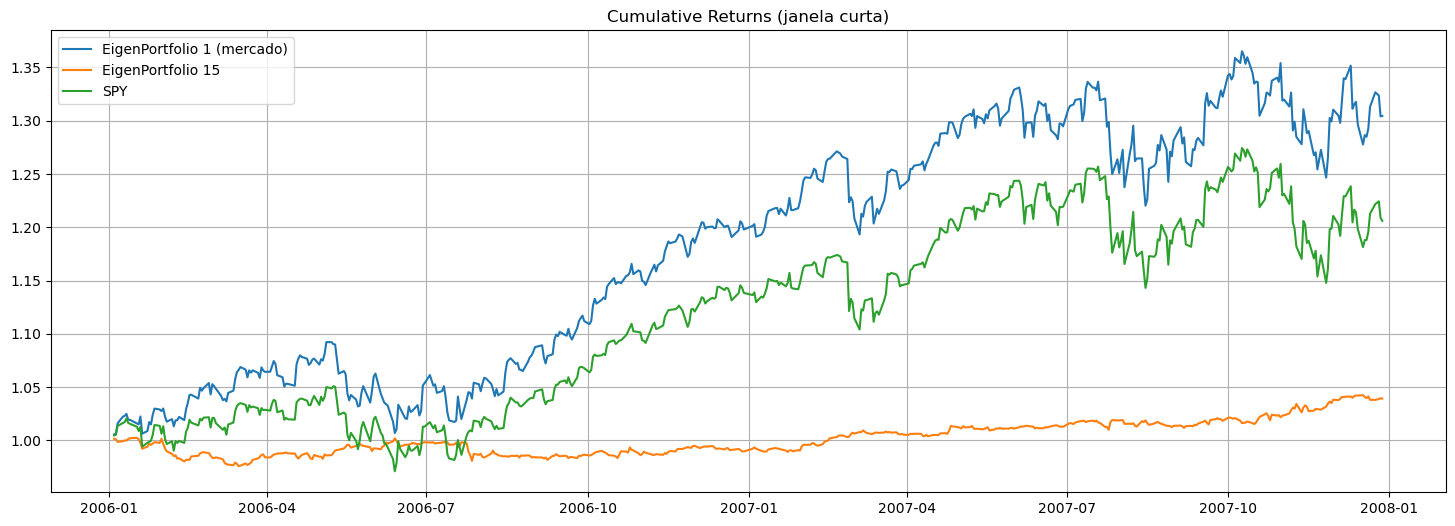

In [14]:
# Pesos do Eigenportifolio de mercado
w1  = eigen_weights(0)    # PC1 ~ "mercado"
w15 = eigen_weights(14)   # PC15

# --- Retornos diários dos fatores ---
F1  = returns.dot(w1) 
F15 = returns.dot(w15)

# --- Retornos acumulados
cum_F1  = (1 + F1).cumprod()
cum_F15 = (1 + F15).cumprod()
cum_SPY = (1 + returns_spy).cumprod()

if isinstance(cum_SPY, pd.DataFrame):
    # tente pelo rótulo; ajuste conforme seu DF
    cum_SPY = cum_SPY['SPY'] if 'SPY' in cum_SPY.columns else cum_SPY.iloc[:, 0]

# --- Garantir DatetimeIndex sem timezone ---
for s in (cum_F1, cum_F15, cum_SPY):
    s.index = pd.to_datetime(s.index).tz_localize(None)
    
# --- Plot ---
plt.figure(figsize=(18,6))
plt.plot(cum_F1,  label='EigenPortfolio 1 (mercado)')
plt.plot(cum_F15, label='EigenPortfolio 15')
plt.plot(cum_SPY, label='SPY')
plt.legend(); plt.grid(True); plt.title('Cumulative Returns (janela curta)')
plt.show()

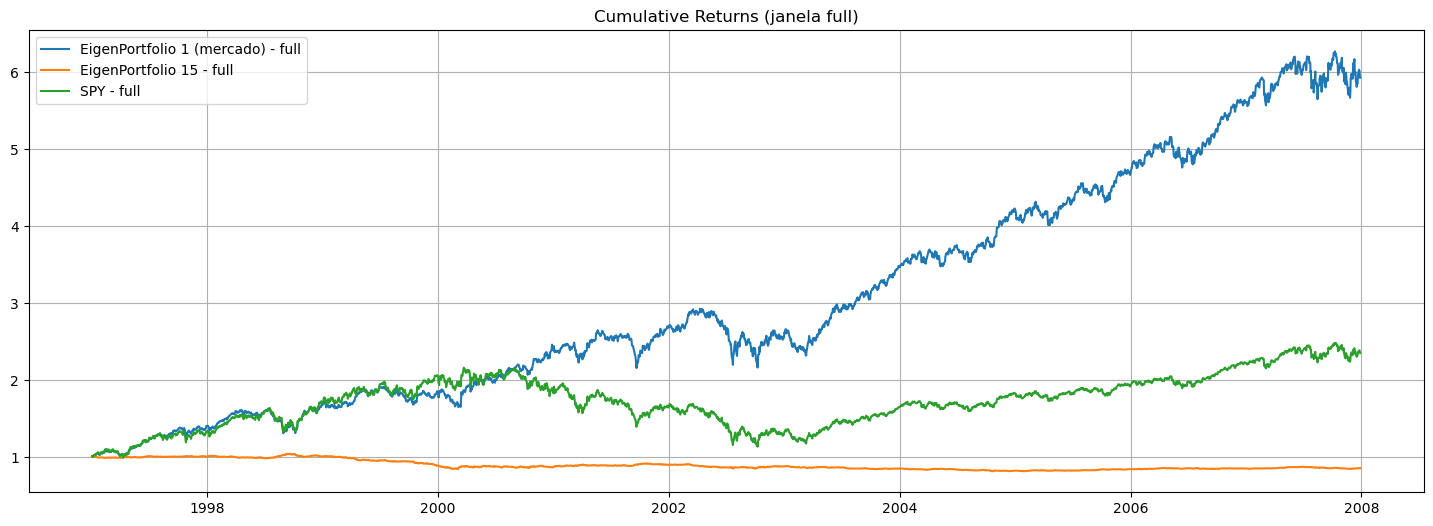

In [15]:
w1_full  = eigen_weights_full(0)
w15_full = eigen_weights_full(14)

F1_full  = returns_full.dot(w1_full)
F15_full = returns_full.dot(w15_full)

cum_F1_full  = (1 + F1_full).cumprod()
cum_F15_full = (1 + F15_full).cumprod()
cum_SPY_full = (1 + returns_spy_full).cumprod()

if isinstance(cum_SPY_full, pd.DataFrame):
    # tente pelo rótulo; ajuste conforme seu DF
    cum_SPY_full = cum_SPY_full['SPY'] if 'SPY' in cum_SPY_full.columns else cum_SPY_full.iloc[:, 0]

# --- Garantir DatetimeIndex sem timezone ---
for s in (cum_F1_full, cum_F15_full, cum_SPY_full):
    s.index = pd.to_datetime(s.index).tz_localize(None)
    
plt.figure(figsize=(18,6))
plt.plot(cum_F1_full,  label='EigenPortfolio 1 (mercado) - full')
plt.plot(cum_F15_full, label='EigenPortfolio 15 - full')
plt.plot(cum_SPY_full, label='SPY - full')
plt.legend(); plt.grid(True); plt.title('Cumulative Returns (janela full)')
plt.show()

Modelo contínuo com $m = 15 $ : $$
\frac{dS_i(t)}{S_i(t)} = \sum_{j=1}^m \beta_{ij} F_j(t) + dX_i(t)
$$

Esse modelo :

* Estima os betas de cada ativo com relação aos fatores

* Extrai os resíduos da regressão, que serão modelados como processo OU

* Calcula os parâmetros do OU: velocidade de reversão (κ), média de longo prazo (m), volatilidade (σ)

* Constroi sinais de reversão à média (s-score) com base nisso

In [16]:
data.head()

,MMM,AOS,ABT,ACN,ADBE,AMD,AES,AFL,A,APD,...,WDC,WY,WSM,WMB,WTW,WYNN,XEL,YUM,ZBRA,ZBH
Date,,,,,,,,,,,,,,,,,,,,,
2006-01-03,37.081547,4.466237,12.043580,20.727745,38.520000,32.400002,10.594819,14.750942,20.099953,34.221111,...,11.519893,12.624354,13.915199,8.324626,62.774403,29.063988,9.076958,11.604428,42.830002,59.318142
2006-01-04,36.894047,4.490475,12.061859,20.840939,38.419998,32.560001,11.046078,14.833289,20.153952,33.830730,...,11.907521,12.929356,13.615329,8.376873,63.426319,29.010126,9.120948,11.703718,42.410000,59.881184
2006-01-05,36.556564,4.448058,12.217154,20.996572,38.070000,33.680000,10.941437,14.953654,20.681948,33.537956,...,11.792443,12.815689,13.455826,8.289795,62.465599,28.837723,9.116060,12.202649,42.529999,59.248859
2006-01-06,36.856556,4.600766,12.451633,22.036497,39.000000,33.779999,11.118017,15.488960,20.789949,34.318707,...,12.052884,12.834638,13.551526,8.321140,61.710732,29.112476,9.150272,12.167892,44.119999,58.945667
2006-01-09,37.039375,4.757120,12.914498,21.972824,38.380001,33.250000,10.928357,15.561815,20.729950,33.882404,...,12.803917,12.804320,13.889683,8.456982,64.215515,30.486214,9.125832,12.262219,44.790001,61.033234


**A ideia geral é**:

* extrair fatores PCA de retornos (em rolling, sem look-ahead),para cada ação, em cada dia, tirar o que é explicado pelos PCs (regressão),

* modelar o resíduo como OU (reversão à média),

* transformar esse OU em um s-score padronizado,

* aplicar regras discretas de entrada/saída por s-score,

* equal-weight por lado (long/short),

* hedgear exposições médias aos PCs,

* normalizar gross, aplicar custos e defasagem de execução,

* acumular PnL e comparar ao SPY.

### Evolução do s-score da JPM ao longo do tempo

### PNL fator PCA

In [17]:
# =============================================================================
# Utilidades gerais
# =============================================================================

def padronizar_janela(df):
    """
    Padroniza cada coluna por média e desvio-padrão (ddof=1) na própria janela.
    Mantém NaN se std==0 ou NaN.
    """
    mu = df.mean()
    sd = df.std(ddof=1).replace(0, np.nan)
    return (df - mu) / sd

def decompor_corr(Z):
    """
    Decompõe a matriz de correlação de Z (colunas padronizadas) via np.linalg.eigh
    e retorna (autovalores decrescentes, autovetores colunarmente ordenados).
    """
    C = Z.corr()
    evals, evecs = np.linalg.eigh(C.values)
    idx = np.argsort(evals)[::-1]
    return evals[idx], evecs[:, idx]

def normalizar_pesos(w: pd.Series | np.ndarray):
    """
    Normaliza pesos para soma das magnitudes = 1 (controle de gross).
    Se tudo for zero, devolve zeros.
    """
    s = np.abs(w).sum()
    if s is None or s == 0 or not np.isfinite(s):
        return w * 0.0
    return w / s


In [18]:
# =============================================================================
# Fatores PCA
# =============================================================================

def compute_pca_factor_returns(returns: pd.DataFrame, eigen_vec, sigma, n_factors: int = 15):
    """
    Constrói fatores eig1...eig_m projetando retornos nos eigenportfólios
    w_j = v_j / sigma, com ||w_j||_1 = 1.

    Retorno
    -------
    DataFrame [date x eig1..eig_m]
    """
    tickers = list(returns.columns)
    F = pd.DataFrame(index=returns.index)

    for j in range(n_factors):
        vj = pd.Series(eigen_vec[:, j], index=tickers)  # autovetor j
        wj = vj / sigma                                
        wj = normalizar_pesos(wj)                          # ||w||_1 = 1
        F[f"eig{j+1}"] = returns.dot(wj)

    return F

def compute_pca_factors_rolling(returns: pd.DataFrame, window_pca: int = 252, n_factors: int = 15):
    """
    Rolling PCA: para cada t (a partir de window_pca),
    - padroniza janela [t-window_pca, t)
    - decompõe a correlação
    - monta pesos w_j = v_j / sigma_j (sigma da janela nos ativos válidos)
    - calcula F_j(t) = Rt · w_j usando retornos do próprio dia t

    Retorna
    -------
    DataFrame com colunas eig1..eig_m
    """
    dates = returns.index
    F = pd.DataFrame(index=dates, columns=[f"eig{i+1}" for i in range(n_factors)], dtype=float)

    for i in range(window_pca, len(dates)):
        t_hist = dates[i - window_pca : i]   # janela [t-252, t)
        t = dates[i]                         # data-alvo

        Rw = returns.loc[t_hist]
        Zw = padronizar_janela(Rw)
        Zw = Zw.dropna(axis=1, how='any')    # exclui colunas com NaN na janela
        Zw = Zw.dropna(axis=0, how='all')   # exclui linhas com NaN na janela
        
        if Zw.shape[1] < n_factors + 1:
            continue

        # PCA na correlação da janela
        _, evecs = decompor_corr(Zw)

        # std dos ativos válidos na janela, para construir w_j
        sigma_w = Rw[Zw.columns].std(ddof=1)

        # retornos do dia t (precisamos de todos válidos nos ativos escolhidos)
        Rt = returns.loc[t, Zw.columns]
        if Rt.isnull().any():
            continue

        for j in range(n_factors):
            vj = pd.Series(evecs[:, j], index=Zw.columns)
            wj = normalizar_pesos(vj / sigma_w)
            F.loc[t, f"eig{j+1}"] = float(Rt.dot(wj))

    return F.dropna(how="all")

A lógica do paper (Avellaneda-Lee style) aqui é **remover** o componente “de mercado” dos ativos via PCs e **tradear** a reversão à média do resíduo

In [21]:
# =============================================================================
# OU e s-score (com centralização cross-sectional do m)
# =============================================================================

def regress_action_on_pcs(X, y):
    """
    1) Ajusta regressão linear: y ~ X  (retorno da ação y com os retornos do PCs X)
    2) Retorna (betas, resíduos epsilon)
    """
    model = LinearRegression().fit(X, y)
    beta = model.coef_
    eps = y - model.predict(X)
    return beta, eps

def estimate_ou_from_cumsum(epsilon):
    """
    Estima OU no passeio acumulado Xk = sum_{j<=k} epsilon_j:
        X_{n+1} = a + b X_n + ζ_{n+1}
    Retorna (a, b, var_zeta, kappa_ann, sigma_eq), ou None se inválido.

    - kappa_ann = -log(b)*252
    - sigma_eq = sqrt(Var(ζ) / (1 - b^2))
    - m = a / (1 - b)   (calculado fora se necessário)
    """
    Xk = np.cumsum(epsilon)
    if len(Xk) < 2:
        return None

    X_ou = Xk[:-1].reshape(-1, 1)
    y_ou = Xk[1:]

    model = LinearRegression().fit(X_ou, y_ou)
    a = float(model.intercept_)
    b = float(model.coef_[0])

    if not np.isfinite(a) or not np.isfinite(b) or not (1e-9 < b < 0.9672):
        return None

    zeta = y_ou - model.predict(X_ou)
    var_zeta = float(np.var(zeta, ddof=1))
    if not np.isfinite(var_zeta) or var_zeta <= 0:
        return None

    kappa_ann = -np.log(b) * 252.0
    sigma_eq = np.sqrt(var_zeta / (1.0 - b**2))
    return a, b, var_zeta, kappa_ann, sigma_eq

def compute_s_scores_cross_sectional(tmp_ret: pd.DataFrame, stocks, num_pc, kappa_min: float = 252.0/30.0): # filtro do paper (~meia-vida < 30d)
    """
    Para um dia t (com janela curta já padronizada em tmp_ret):
    - Para cada ação: regressão ação~PCs → resíduos → OU → (a,b,var, kappa, sigma_eq)
    - Calcula m_i = a/(1-b) por ação válida
    - Centraliza m_i: m_i* = m_i - mean_j(m_j)
    - s_i = - m_i* / sigma_eq_i
    Retorna:
      s_scores_t (Series por ação), betas_t (dict ação->vetor de betas) de todas as ações naquele dia
    """
    pcs = [f"eig{i+1}" for i in range(num_pc)]
    s_t = pd.Series(index=stocks, dtype=float)
    betas_t = {}
    m_map = {}
    sigma_eq_map = {}

    X_mat = tmp_ret[pcs].values                   # tabela dos retornos dos PCs

    for stock in stocks:
        y = tmp_ret[stock].values                 # tabela dos retornos da ação específica
        if np.isnan(y).any() or np.isnan(X_mat).any():
            continue

        beta, eps = regress_action_on_pcs(X_mat, y)
        ou = estimate_ou_from_cumsum(eps)          # return a, b, var_zeta, kappa_ann, sigma_eq
        if ou is None:
            continue

        a, b, var_zeta, kappa_ann, sigma_eq = ou
        if kappa_ann <= kappa_min:
            # reverte devagar demais segundo o critério do paper
            continue

        m = a / (1.0 - b)
        m_map[stock] = m
        sigma_eq_map[stock] = sigma_eq
        betas_t[stock] = beta

    if not m_map:
        return s_t, betas_t  # vazio

    # centralização cross-sectional (média simples dos válidos)
    m_bar = np.mean(list(m_map.values()))
    for stock, m in m_map.items():
        s_val = -(m - m_bar) / sigma_eq_map[stock]  # melhor até agora
        #s_val = -m / sigma_eq_map[stock] 
        #s_val = - m_bar / sigma_eq_map[stock]  # acredito que seja assim , ficou pior
        if np.isfinite(s_val):
            s_t.loc[stock] = s_val

    return s_t, betas_t

In [45]:
# =============================================================================
# Regras de posição, hedge e PnL
# =============================================================================

def position_from_s(
    s: float,            # s-score do dia (escalares)
    pos_prev: float,     # {-1, 0, +1}
    sbo: float = 1.25,   # buy-to-open se s < -sbo
    sso: float = 1.25,   # sell-to-open se s > +sso
    sbc: float = 0.75,   # close short se s < +sbc
    ssc: float = 0.50,   # close long  se s > -ssc
):

    if pd.isna(s):
        return pos_prev

    pos = pos_prev

    # Aberturas (prioridade)
    if s > +sso:
        pos = -1.0
    elif s < -sbo:
        pos = +1.0

    # Fechamentos (aplicados se não houve nova abertura)
    elif (s < +sbc) and (pos_prev == -1.0):
        pos = 0.0
    elif (s > -ssc) and (pos_prev == +1.0):
        pos = 0.0

    return pos

def equal_weight_by_side(row_pos: pd.Series):
    """
    Converte posições discretas {-1,0,+1} em pesos por lado (long/short)
    com igual peso dentro de cada lado; neutros ficam 0.
    """
    tmp = row_pos.astype(float).copy()
    longs = tmp > 0
    shorts = tmp < 0
    nL = longs.sum()
    nS = shorts.sum()

    # if nL > 0:
    #     tmp.loc[longs] = +1.0 / float(nL)
    # else:
    #     tmp.loc[longs] = 0.0

    # if nS > 0:
    #     tmp.loc[shorts] = -1.0 / float(nS)
    # else:
    #     tmp.loc[shorts] = 0.0

    # tmp.loc[~longs & ~shorts] = 0.0
    
    tmp.loc[longs] = +1.0 / float(nL)
    tmp.loc[shorts] = -1.0 / float(nS)
    
    return tmp

def hedge_from_betas(
    algo_weights: pd.DataFrame,
    betas: pd.DataFrame,
    stocks,
    pcs):
    """
    Calcula hedge nos PCs neutralizando a exposição média:
      hedge_t = - sum_s( w_s(t) * beta_s(t) )
    Saída é DataFrame [date x pcs] com pesos de hedge.
    """
    # garante vetores NumPy coerentes; substitui inválidos por zeros
    beta_bar = betas.apply(
        lambda col: col.map(lambda v: v if (isinstance(v, np.ndarray) and v.shape == (len(pcs),)) else np.zeros(len(pcs)))
    )

    hedge_vec = []
    for dt in algo_weights.index:
        row = beta_bar.loc[dt, stocks].values
        b_dt = np.vstack(row) if len(row) else np.zeros((0, len(pcs)))
        w_dt = algo_weights.loc[dt, stocks].values.reshape(-1, 1)
        expo = (b_dt * w_dt).sum(axis=0)  # exposição média por PC
        hedge_vec.append(-expo)           # sinal oposto → neutraliza
    hedge = pd.DataFrame(hedge_vec, index=algo_weights.index, columns=pcs)
    return hedge

def normalize_gross(w_all: pd.DataFrame, gross_target: float = 1.0):
    """
    Normaliza linha-a-linha para que ∑|w_i| = gross_target (por padrão =1).
    """
    gross = w_all.abs().sum(axis=1).replace(0, np.nan)
    W = w_all.div(gross, axis=0).fillna(0.0)
    W *= gross_target
     
    return W

def compute_pnl_with_costs(
    w_all: pd.DataFrame,
    returns_mod: pd.DataFrame,
    cols_trade,
    eps_per_turnover: float = 0.0005) :
    """
    Calcula retorno líquido usando:
      - execução com pesos defasados de 1 dia (w_shift)
      - custo linear em turnover (∑ |Δw_i|)
    Retorna (ret_net, cumret, turnover).
    """
    # evita vazamento: primeiro dia não tem posição -> 0
    w_shift = w_all.shift(1).fillna(0.0)

    rets = returns_mod.loc[w_shift.index, cols_trade]
    ret_gross = (rets * w_shift[cols_trade]).sum(axis=1)

    turnover = (w_all - w_all.shift(1)).abs().sum(axis=1).fillna(0.0)
    ret_net = ret_gross - eps_per_turnover * turnover

    cumret = (1.0 + ret_net.fillna(0.0)).cumprod()
    return ret_net, cumret, turnover

In [59]:
# =============================================================================
# Função principal (backtest)
# =============================================================================

def n_pca_portfolio_spy(
    modified_returns: pd.DataFrame,
    returns_all: pd.DataFrame,
    num_pc: int = 15,
    l_win: int = 252,
    s_win: int = 60,
    # thresholds do paper:
    sbo: float = 1.25,
    sso: float = 1.25,
    sbc: float = 0.75,
    ssc: float = 0.50,
    eps_cost: float = 0.0005,
    gross_target: float = 1.0,
    plot: bool = True,
):
    """
    Backtest:
      - modified_returns: DataFrame com [ações] + eig1..eig{num_pc}
      - returns_all: modified_returns + 'SPY'
      - gera s-scores centrados, posições discr., equal-weight por lado
      - hedge nos PCs por beta médio
      - normaliza gross e calcula PnL com custos

    Retorna:
      cumret_algo (Series) e s_scores (DataFrame [date x stocks])
    """
    pcs = [f"eig{i+1}" for i in range(num_pc)]
    stocks = [c for c in returns_all.columns if c not in (["SPY"] + pcs)]
    usable_index = returns_all.iloc[l_win:].index

    # contêineres
    s_scores = pd.DataFrame(index=usable_index, columns=stocks, dtype=float)
    betas = pd.DataFrame(index=usable_index, columns=stocks, dtype=object)
    algo_pos = pd.DataFrame(index=usable_index, columns=stocks, dtype=float)

    # ------------- loop temporal -------------
    for t in usable_index:
        # janela curta [t-s_win+1, t] para padronização e estimação
        tmp_ret = modified_returns.loc[:t].iloc[-s_win:].copy()
        tmp_ret = padronizar_janela(tmp_ret)

        # checagem: PCs não podem ter NaN nessa janela padronizada
        if tmp_ret[pcs].isnull().any().any():
            continue

        # s-scores para o dia t (com centralização) + betas para hedge
        s_t, betas_t = compute_s_scores_cross_sectional(
            tmp_ret=tmp_ret,
            stocks=stocks,
            num_pc=num_pc,
            kappa_min=252.0/30.0,
        )

        # guarda s-scores e betas válidos
        s_scores.loc[t, s_t.index] = s_t
        for k, v in betas_t.items():
            betas.loc[t, k] = v

        # atualiza posições discretas com base no s-score de cada ação
        if t == usable_index[0]:
            prev = pd.Series(0.0, index=stocks)
        else:
            prev = algo_pos.loc[usable_index[usable_index.get_loc(t)-1]]

        new_pos = []
        for s_name in stocks:
            s_val = s_t.get(s_name, np.nan)
            new_pos.append(
                position_from_s(
                    s=s_val,
                    pos_prev=prev.get(s_name, 0.0),
                    sbo=sbo, sso=sso, sbc=sbc, ssc=ssc
                )
            )
        algo_pos.loc[t] = new_pos

    # remove linhas sem s-score algum (segurança)
    null_idx = s_scores.index[s_scores.isnull().all(axis=1)]
    s_scores = s_scores.drop(index=null_idx)
    betas = betas.drop(index=null_idx)
    algo_pos = algo_pos.drop(index=null_idx)

    # pesos iguais por lado
    algo_weights = algo_pos.apply(equal_weight_by_side, axis=1, result_type="broadcast")

    # hedge por PCs
    hedge = hedge_from_betas(algo_weights, betas, stocks, pcs)

    # junta pesos (ações + PCs) e normaliza gross
    w_all = pd.concat([algo_weights, hedge], axis=1)
    w_all = normalize_gross(w_all, gross_target=gross_target)

    # retornos utilizados no trade (ações + PCs)
    cols_trade = stocks + pcs
    ret_net, cumret_algo, turnover = compute_pnl_with_costs(
        w_all=w_all,
        returns_mod=modified_returns,
        cols_trade=cols_trade,
        eps_per_turnover=eps_cost,
    )

    # comparação com SPY (buy&hold em retorno simples)
    spy = returns_all.loc[cumret_algo.index, "SPY"].fillna(0.0)
    cumret_spy = (1.0 + spy).cumprod()

    if plot:
        plt.figure(figsize=(18, 6))
        plt.grid(True)
        plt.plot(cumret_algo.index, cumret_algo, label='Algo (PCA-OU)')
        plt.plot(cumret_spy.index,  cumret_spy,  label='SPY')
        plt.legend()
        plt.title(f'Estratégia PCA/OU vs SPY | PCs={num_pc}, l_win={l_win}, s_win={s_win}')
        plt.show()

    return cumret_algo, s_scores

In [49]:
# 1) Índices coerentes e ordenados (sem timezone)
returns_full.index     = pd.to_datetime(returns_full.index).tz_localize(None)
returns_spy_full.index = pd.to_datetime(returns_spy_full.index).tz_localize(None)
returns_full     = returns_full.sort_index()
returns_spy_full = returns_spy_full.sort_index()

# 2) Quantos PCs
NUM_PC = 15

# 3) Fatores PCA (rolling) com janela de 252 dias
F_full_roll = compute_pca_factors_rolling(
    returns_full, window_pca=252, n_factors=NUM_PC
)

# 4) Monta base final: ações + PCs + SPY
modified_returns_full = pd.concat([returns_full, F_full_roll], axis=1).dropna()
spy = returns_spy_full.copy()
spy.name = "SPY"
returns_all_full = modified_returns_full.join(spy, how="inner")

print("modified_returns_full:", modified_returns_full.shape)
print("SPY:", spy.shape)
print("returns_all_full:", returns_all_full.shape)
assert len(returns_all_full) > 0, "returns_all_full ficou vazio após o join"

modified_returns_full: (2513, 330)
SPY: (2765, 1)
returns_all_full: (2513, 331)


In [50]:
F_full_roll

,eig1,eig2,eig3,eig4,eig5,eig6,eig7,eig8,eig9,eig10,eig11,eig12,eig13,eig14,eig15
Date,,,,,,,,,,,,,,,
1998-01-02,-0.000963,0.003613,0.003794,-0.000402,0.003291,-0.000156,-0.004920,-0.001957,0.002386,0.001421,-0.001826,-0.001485,-0.000073,-0.001149,-0.001076
1998-01-05,0.001022,0.005182,0.002155,-0.004770,0.001926,0.004474,0.001671,0.001311,-0.002857,-0.000505,0.000099,0.002473,0.000419,0.000534,0.000468
1998-01-06,0.007532,0.001115,0.001524,-0.000101,-0.001402,0.003816,0.000389,-0.000466,0.001002,0.001117,0.000429,0.001588,0.001054,-0.001842,0.000546
1998-01-07,0.004546,-0.001780,0.001548,0.001101,-0.005340,-0.000830,0.000488,-0.001595,0.000888,-0.000848,-0.000220,0.001021,-0.000052,0.002457,-0.001198
1998-01-08,0.005472,-0.000452,0.000646,0.004473,0.004841,0.002495,0.000335,-0.001645,-0.001818,-0.000628,-0.003301,-0.001679,0.001412,0.000179,0.002452
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2007-12-21,-0.015592,-0.001048,0.000363,0.002351,-0.001808,-0.004580,0.004352,0.001649,0.000529,-0.002599,-0.000315,0.000940,-0.000118,-0.001723,0.002327
2007-12-24,-0.009634,0.004369,0.002569,0.000490,-0.001457,0.002484,0.000156,0.002665,-0.000911,0.000978,-0.002198,0.000048,-0.000279,0.000227,0.000841
2007-12-26,0.002380,-0.004168,0.002535,-0.001250,0.000222,-0.002927,-0.000443,0.000445,0.001125,-0.000418,0.000073,-0.000353,-0.001316,-0.001281,-0.000078


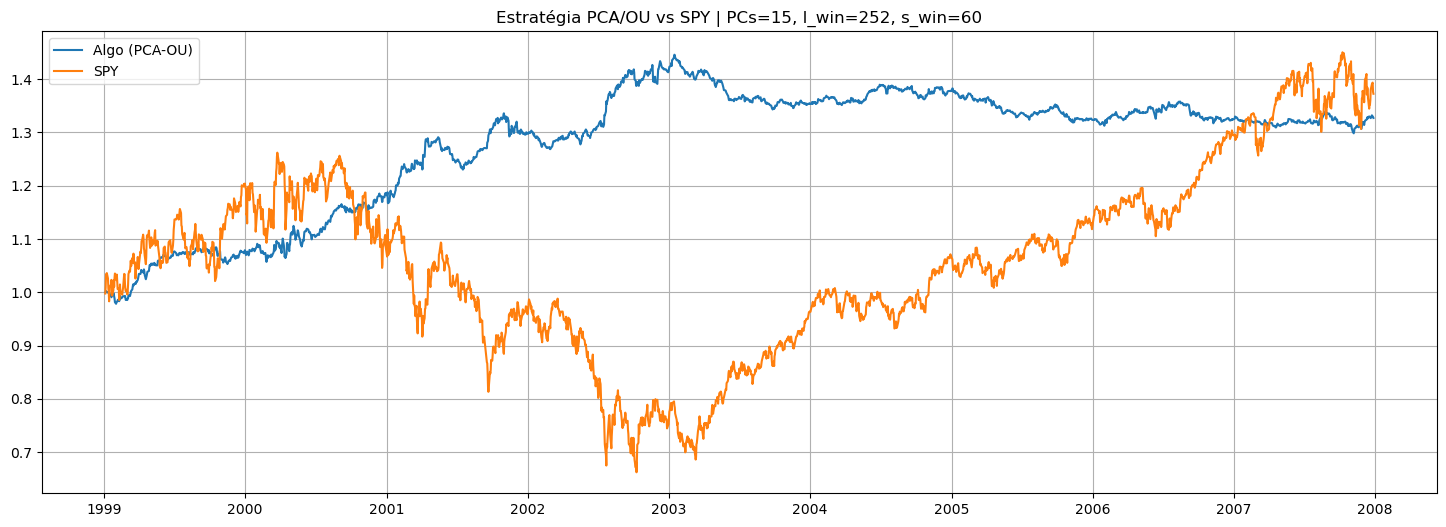

In [51]:
# Roda o backtest
cum_algo, s_scores = n_pca_portfolio_spy(
    modified_returns=modified_returns_full,
    returns_all=returns_all_full,
    num_pc=NUM_PC,
    l_win=252,          # ~1 ano para "esquentar"
    s_win=60,           # janela de estimação (paper)
    sbo=1.25,           # buy-to-open se s < -sbo
    sso=1.25,           # sell-to-open se s > +sso
    sbc=0.75,           # close short se s < +sbc
    ssc=0.50,           # close long  se s > -ssc
    eps_cost=0.0005,    # 5 bps por turnover (use 0.001 p/ ~10 bps round-trip)
    gross_target=1.0,   # normalização da exposição bruta
    plot=True,
)

In [52]:
def stats_from_returns(ret):
    ann = 252
    cagr = (1+ret).prod()**(ann/len(ret)) - 1
    vol  = ret.std(ddof=1) * np.sqrt(ann)
    sharpe = cagr/vol if vol>0 else np.nan
    # max drawdown
    cum = (1+ret).cumprod()
    peak = cum.cummax()
    dd = (cum/peak - 1).min()
    return {"CAGR": cagr, "Vol": vol, "Sharpe": sharpe, "MaxDD": dd}

ret_series = cum_algo.pct_change().dropna()
stats_from_returns(ret_series)

{'CAGR': 0.032057567019848854,
 'Vol': 0.04464188052258948,
 'Sharpe': 0.718105210725324,
 'MaxDD': -0.10201964803693198}

In [57]:
cum_algo

Date
1999-01-04    1.000000
1999-01-05    1.000909
1999-01-06    1.002166
1999-01-07    0.999995
1999-01-08    1.000862
                ...   
2007-12-21    1.326682
2007-12-24    1.331941
2007-12-26    1.329911
2007-12-27    1.328853
2007-12-28    1.327090
Length: 2261, dtype: float64

In [ ]:
# Roda o backtest (assinatura nova com quatro limiares)
cum_algo, s_scores = n_pca_portfolio_spy(
    modified_returns=modified_returns_full,
    returns_all=returns_all_full,
    num_pc=NUM_PC,
    l_win=252,          # ~1 ano para "esquentar"
    s_win=60,           # janela de estimação (paper)
    sbo=1.25,           # buy-to-open se s < -sbo
    sso=1.25,           # sell-to-open se s > +sso
    sbc=0.50,           # close short se s < +sbc
    ssc=0.50,           # close long  se s > -ssc
    eps_cost=0.0005,    # 5 bps por turnover (use 0.001 p/ ~10 bps round-trip)
    gross_target=1.0,   # normalização da exposição bruta
    plot=True,
)

In [ ]:
ret_series = cum_algo.pct_change().dropna()
stats_from_returns(ret_series)

In [ ]:
cum_algo